In [ ]:
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn

^C
Defaulting to user installation because normal site-packages is not writeable


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [5]:
df = pd.read_csv('data.csv')

In [25]:
df.InternetService.unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [79]:
df.groupby('InternetService').MonthlyCharges.agg([min, max, len]).reset_index().sort_values(by='min')

C:\Users\Muhammad Hamza\AppData\Local\Temp\ipykernel_13944\2502849215.py:1: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df.groupby('InternetService').MonthlyCharges.agg([min, max, len]).reset_index().sort_index()
C:\Users\Muhammad Hamza\AppData\Local\Temp\ipykernel_13944\2502849215.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df.groupby('InternetService').MonthlyCharges.agg([min, max, len]).reset_index().sort_index()


,InternetService,min,max,len
0,DSL,23.45,94.80,2421
1,Fiber optic,67.75,118.75,3096
2,No,18.25,26.90,1526


In [111]:
df.astype(str, copy=False).dtypes

customerID          object
gender              object
SeniorCitizen       object
Partner             object
Dependents          object
tenure              object
PhoneService        object
MultipleLines       object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
Contract            object
PaperlessBilling    object
PaymentMethod       object
MonthlyCharges      object
TotalCharges        object
Churn               object
dtype: object

## DATASET INFO

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [31]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [35]:
df.isnull().sum().sum()

0

In [39]:
df.duplicated().sum()

0

Now checking duplicate based on unique value column

In [45]:
df['customerID'].duplicated().sum()

0

## TRANSFORMING DATA

Total Carges column have object datatyoe instead of float. The reason identified by looking the csv file is that that it contains empty strings as well. So we first need to convert those empty strings to 0 (as they have 0 tenure value so __tenure*MonthlyChareges=TotalCharges__). So first we will convert to 0 and then convert data type to float


In [21]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", 0)
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Converting 0 and 1 to yes and no of Senior Citizen data

In [50]:
def con(val):
    if val == 1: return 'yes'
    return 'no'

df['SeniorCitizen'] = df['SeniorCitizen'].map(con)

In [52]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## CHURN ANALYSIS

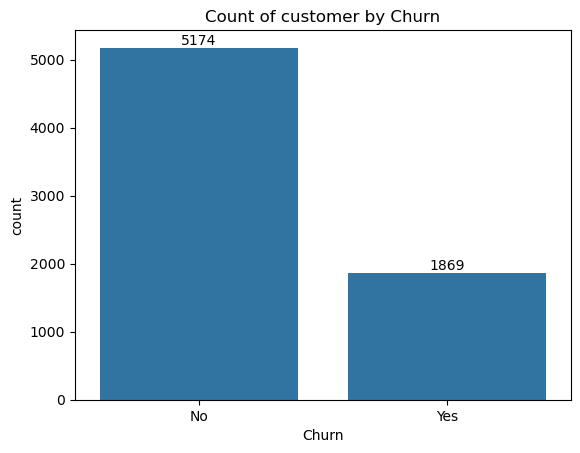

In [114]:
ax = sns.countplot(x ='Churn', data = df)

ax.bar_label(ax.containers[0])
plt.title('Count of customer by Churn')
plt.show()

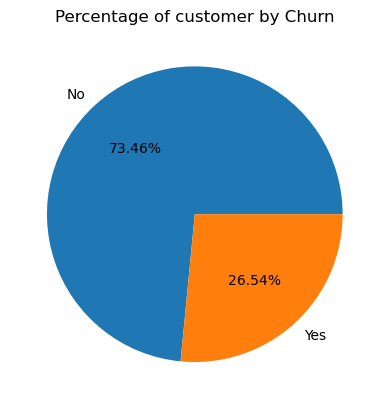

In [116]:
gb = df.groupby('Churn').agg({'Churn': 'count'})

plt.pie(gb['Churn'], labels=gb.index, autopct='%1.2f%%')
plt.title('Percentage of customer by Churn')
plt.show()

In [118]:
# From the Chart we can conclude that 27% of our customers have churned out
# Now figuring out the reason

## Churn Analaysis Based On Gender

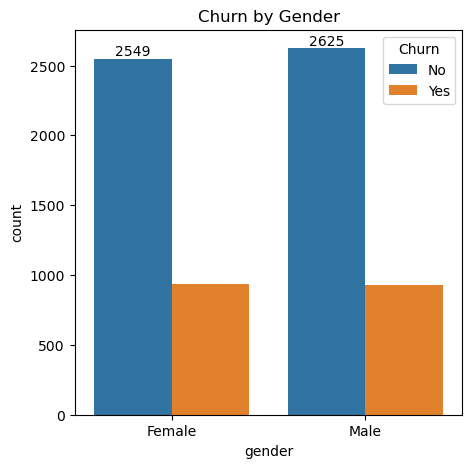

In [156]:
plt.figure(figsize=(5, 5))
ax = sns.countplot(x ='gender', data = df, hue='Churn')

ax.bar_label(ax.containers[0])
plt.title('Churn by Gender')
plt.show()

In [134]:
# From above graph we can conclude that churn is independent of the gender

## Churn Analysis Based On Senior Citizen

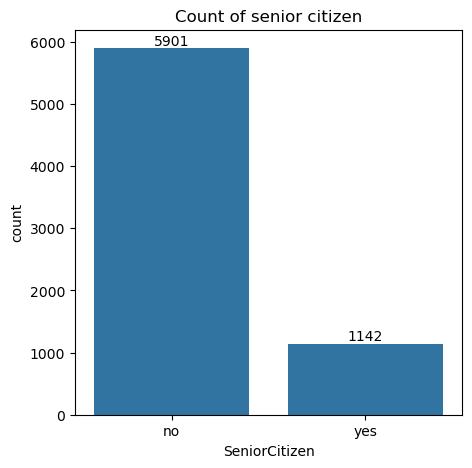

In [200]:
plt.figure(figsize=(5, 5))
ax = sns.countplot(x='SeniorCitizen', data=df)

ax.bar_label(ax.containers[0])
plt.title('Count of senior citizen')
plt.show()

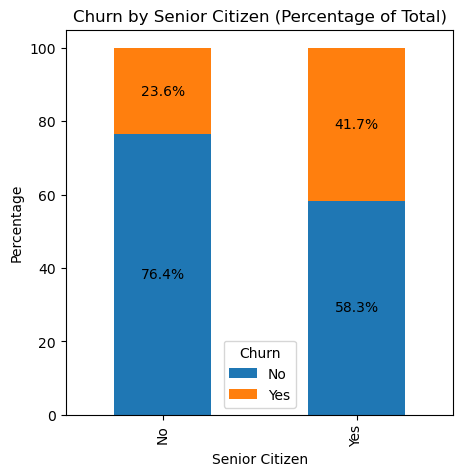

In [194]:
count_data = df.groupby(['SeniorCitizen', 'Churn']).size().unstack().fillna(0)
percentage_data = count_data.div(count_data.sum(axis=1), axis=0) * 100

# Plot a stacked bar chart with percentages
ax = percentage_data.plot(kind='bar', stacked=True, figsize=(5, 5))

# Add labels to show the percentage on top of the bars
for p in ax.patches:
    height = p.get_height()
    width = p.get_width()
    x = p.get_x() + width / 2
    y = p.get_height() / 2 + p.get_y()
    
    if height > 0:  # Only annotate if the bar has height (avoid cluttering)
        ax.annotate(f'{height:.1f}%', (x, y), ha='center', va='center', fontsize=10, color='black')

# Title and labels
plt.title('Churn by Senior Citizen (Percentage of Total)')
plt.xlabel('Senior Citizen')
plt.ylabel('Percentage')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [202]:
# Comparative a greater percentage of people in senior citizen category have churned out

## Churn Analysis Based On Tenure

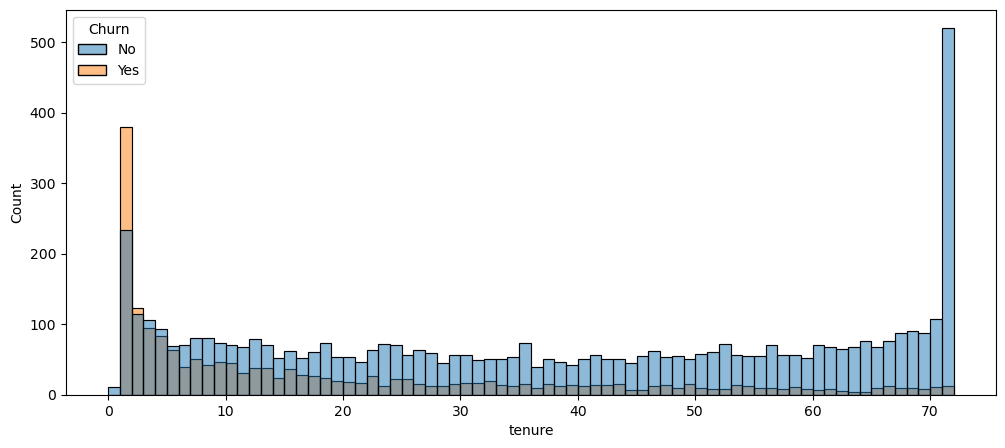

In [221]:
plt.figure(figsize=(12, 5))

sns.histplot(x='tenure', data = df, bins=72, hue='Churn') # 72 is max value in tenure column
plt.show()

In [ ]:
# People who have used our services for long time have stayed and people who have used for 1 or 2 months have churned

## Churn Analysis Based On Contarct

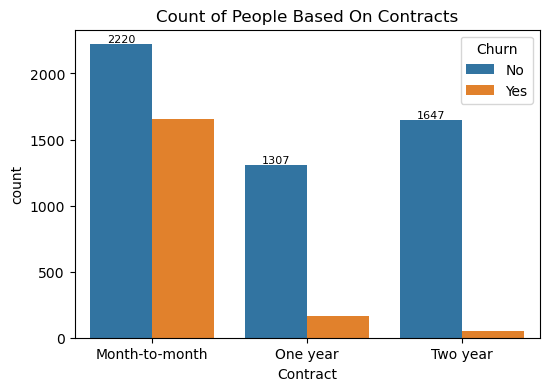

In [247]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Contract', data=df, hue='Churn')
ax.bar_label(ax.containers[0], fontsize=8)
plt.title('Count of People Based On Contracts')
plt.show()

In [249]:
# People who have month to month contract are likely to churn than those who have 1 or 2 years of contract  

## Churn Analysis On Collective Data

In [256]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

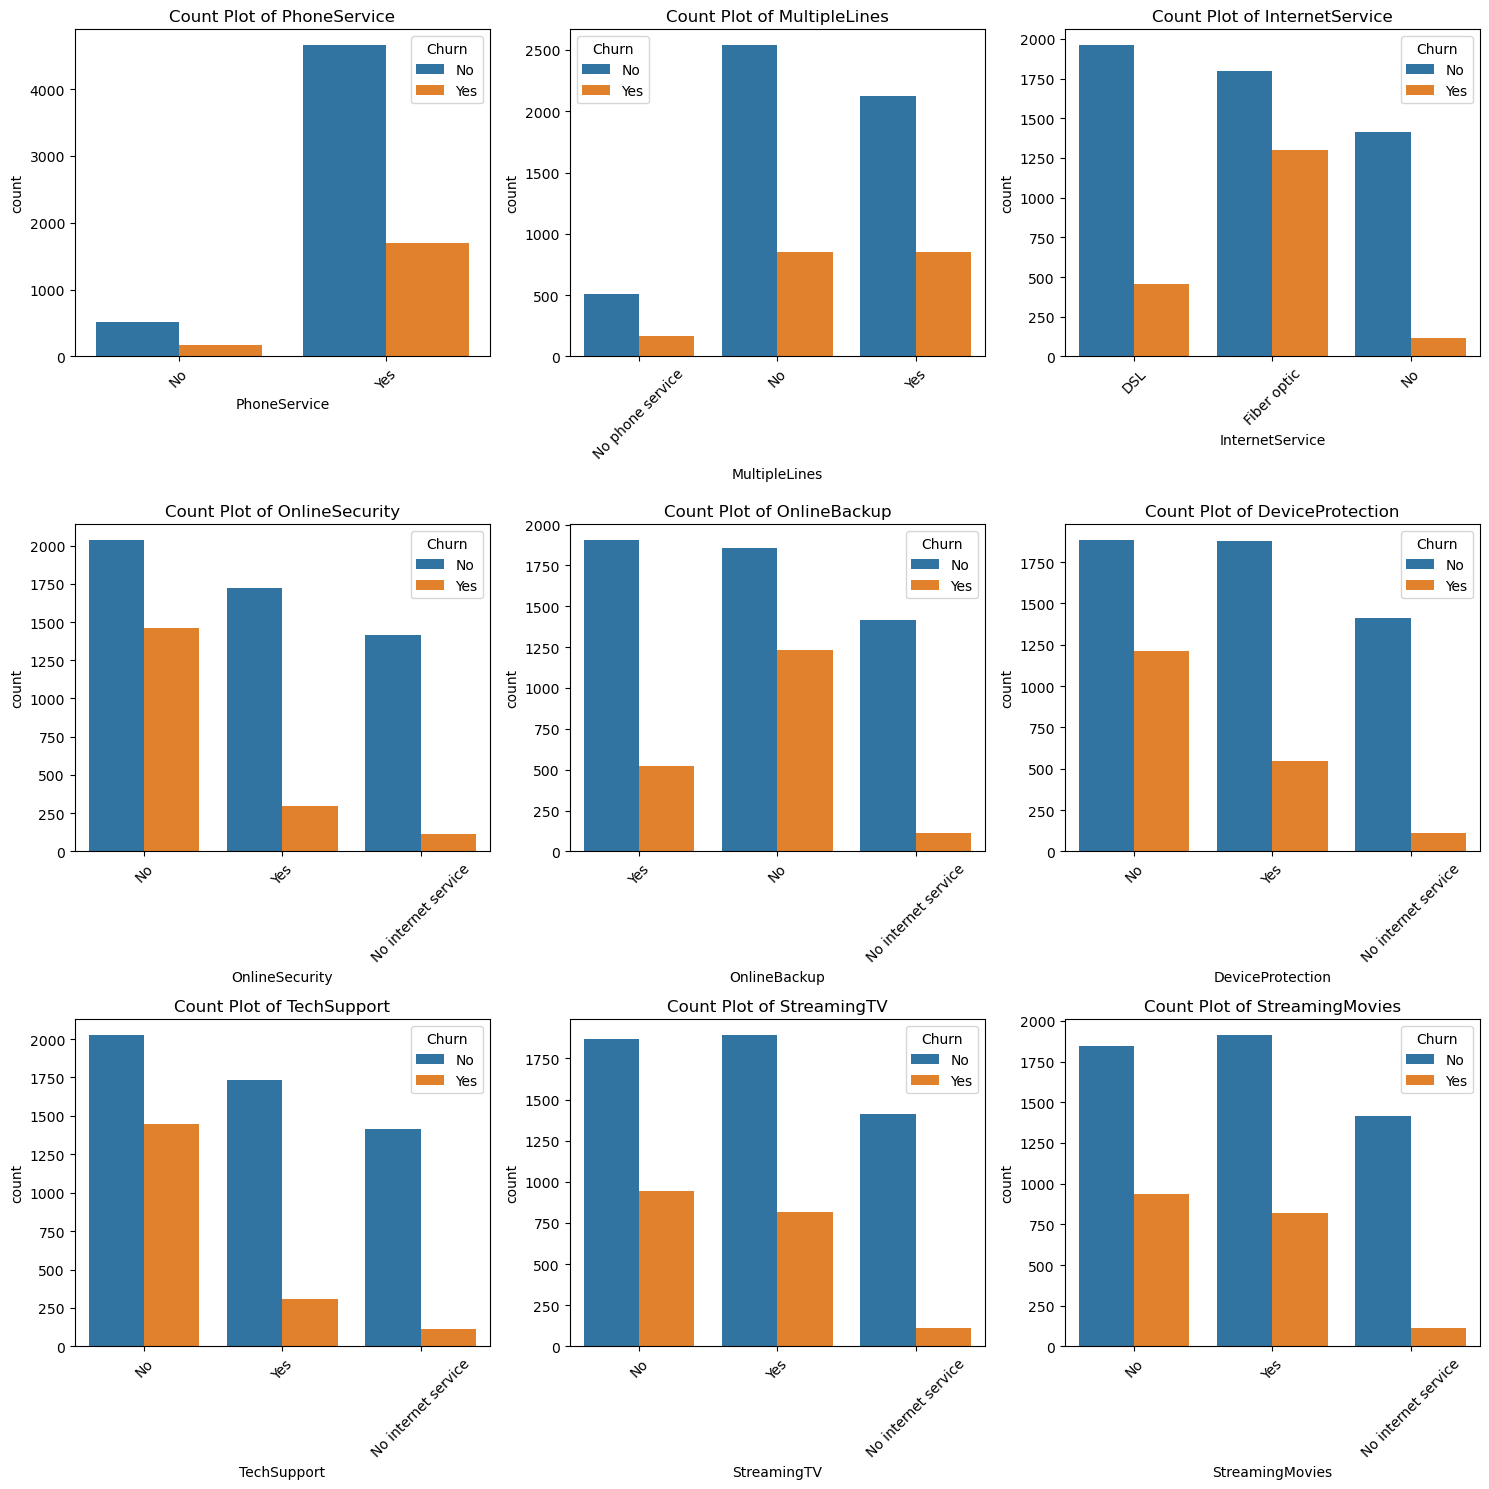

In [260]:
columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Set the size of the plot grid (rows, columns)
n_cols = 3  # You can adjust the number of columns in your subplot grid
n_rows = (len(columns) + n_cols - 1) // n_cols  # Calculate the number of rows needed

# Create a subplot figure
plt.figure(figsize=(15, n_rows * 5))

# Loop through the columns and create count plots
for i, col in enumerate(columns, 1):
    plt.subplot(n_rows, n_cols, i)  # Position the subplot
    sns.countplot(data=df, x=col, hue='Churn')  # Create the count plot
    plt.title(f'Count Plot of {col}')  # Set title for each plot
    plt.xticks(rotation=45)  # Rotate x-axis labels if needed for better readability

# Adjust layout for better spacing between plots
plt.tight_layout()

# Show the plots
plt.show()

In [264]:
# Majority of customers who do not churn tend to have services like PhoneServices, InternetServices(particularly DSL) and online security enabled.
# For services like OnlineBackup, TechSupport and StreamingTV, churn rates are noticable higher when these services are not used or unavailable.

## Churn Analysis Based On Payment Method

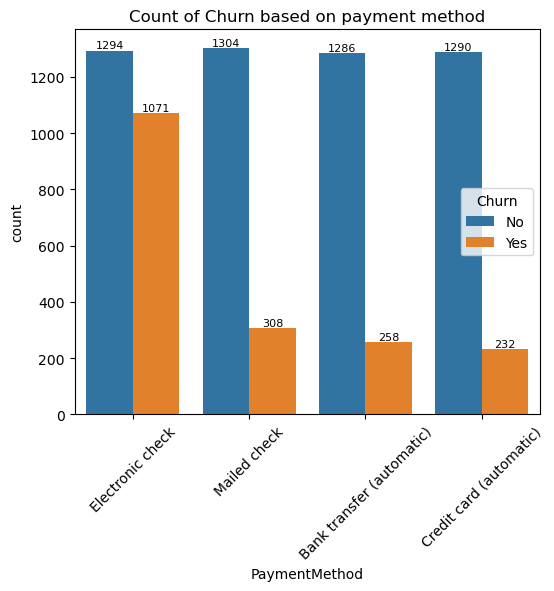

In [275]:
plt.figure(figsize=(6,5))

ax= sns.countplot(x='PaymentMethod', data=df, hue='Churn')
ax.bar_label(ax.containers[0], fontsize=8)
ax.bar_label(ax.containers[1], fontsize=8)
plt.title('Count of Churn based on payment method')
plt.xticks(rotation = 45)
plt.show()

In [279]:
# Customer is likely to churn when he is using electronic method as a payment method